# Machine Learning Notebook: Bagging (Bootstrap Aggregating)

## 1. Structural Overview & Core Nomenclature

---

## > Bagging Architecture

```text
                +---------------------------------+
                |      Master Training Data (D)   |
                +---------------------------------+
                                 |
         +-----------------------+-----------------------+
         | (Row Sampling with/without replacement)       |
         v                                               v
+-----------------+                             +-----------------+
|   Subset (D₁)   |                             |   Subset (Dₘ)   |
+-----------------+                             +-----------------+
         |                                               |
         v                                               v
+-----------------+                             +-----------------+
|   Base Model 1  |                             |   Base Model M  |
|  (Estimator 1)  |                             |  (Estimator M)  |
+-----------------+                             +-----------------+
         |                                               |
         v                                               v
+-----------------------------------------------------------------+
|                      AGGREGATION STAGE                          |
|  - Classification: Majority Voting (Mode)                      |
|  - Regression: Average Prediction (Mean)                       |
+-----------------------------------------------------------------+
```

---

Bagging is one of the most powerful and widely used ensemble paradigms in Machine Learning.

The name itself is a portmanteau representing a two-stage process:

$$
\text{Bootstrap} + \text{Aggregating} = \text{Bagging}
$$

Bagging works by training multiple versions of the same model on different subsets of data and then combining their predictions to produce a more stable and accurate result.

### The Two Pillars of Bagging

#### 1. Bootstrapping (Data Splitting)

Instead of training every base model on the exact same dataset, multiple subsets are generated from the master dataset.

$$
D \rightarrow D_1, D_2, D_3, \dots, D_M
$$

These subsets are created using random sampling, traditionally with replacement.

#### 2. Homogeneous Base Models

Unlike Voting Ensembles, which combine different machine learning algorithms, Bagging generally uses the same underlying algorithm across all estimators.

Examples:

* Decision Tree + Decision Tree + Decision Tree
* KNN + KNN + KNN

#### 3. Aggregating (Result Integration)

When a new observation

$$
X_{new}
$$

is passed into the ensemble, every base model produces a prediction.

**For Classification:**

The final prediction is determined using Majority Voting (Mode).

**For Regression:**

The final prediction is determined using the Mathematical Mean (Average).

---

## 2. Mathematical Motivation: Bias-Variance Tradeoff

The primary reason Bagging works is its ability to reduce Variance while preserving the strengths of powerful models.

### The Bias-Variance Dilemma

Machine learning errors are largely influenced by two components:

### Bias

Bias is the error introduced due to overly simplistic assumptions.

High Bias generally leads to:

* Underfitting
* Poor training performance
* Poor testing performance

### Variance

Variance measures how sensitive a model is to fluctuations in the training data.

High Variance generally leads to:

* Overfitting
* Excellent training performance
* Poor testing performance

Many powerful models such as fully-grown Decision Trees naturally possess:

$$
\text{Low Bias}
$$

and

$$
\text{High Variance}
$$

These models fit the training data extremely well but often fail to generalize to unseen data.

---

## 3. How Bagging Reduces Variance

Bagging significantly reduces Variance while maintaining the low Bias of individual estimators.

### Isolation of Outliers

Since every estimator sees a different bootstrap sample, noisy observations and outliers only affect a subset of the models.

### Smoothing Through Aggregation

Extreme predictions generated by individual estimators are averaged out during aggregation.

### Stable Predictions

The ensemble produces more stable predictions even when small changes occur in the training dataset.

The overall objective can be summarized as:

$$
\text{Low Bias} + \text{Low Variance}
=
\text{Better Generalization}
$$
---

## 4. Four Core Variations of Bagging

### A. Standard Bagging

#### Row Sampling

Enabled with replacement.

A particular row can appear multiple times within the same subset.

#### Column Sampling

Disabled.

Every estimator sees all available features.

---

## > Types of Bagging

Depending on how rows and columns are sampled, Bagging can be divided into four variants.

```text
                              [ Bagging Variations ]
                                         |
         +-------------------------------+-------------------------------+
         |                                                               |
         v                                                               v
  +--------------+                                                +--------------+
  |  Row         |                                                | Column       |
  |  Sampling    |                                                | Sampling     |
  +--------------+                                                +--------------+
    |          |                                                    |          |
    v          v                                                    v          v
+---------+ +---------+                                      +-----------+ +-----------+
| Bagging | | Pasting |                                      | Random    | | Random    |
|         | |         |                                      | Subspaces | | Patches   |
+---------+ +---------+                                      +-----------+ +-----------+
```

---



### B. Pasting

#### Row Sampling

Enabled without replacement.

No duplicate rows appear inside a subset.

#### Column Sampling

Disabled.

Every estimator sees all available features.

---

### C. Random Subspaces

#### Row Sampling

Disabled.

Every estimator sees all training rows.

#### Column Sampling

Enabled.

Only a subset of features is used for training each estimator.

#### Common Applications

* Natural Language Processing
* Image Processing
* High-Dimensional Datasets

---

### D. Random Patches

#### Row Sampling

Enabled.

#### Column Sampling

Enabled.

Each estimator receives both:

* A subset of rows
* A subset of columns

This maximizes diversity among base models.

---

## 5. Why Bagging Works So Well

Bagging is particularly effective for models suffering from High Variance.

Examples include:

* Deep Decision Trees
* Unpruned Trees

Because each estimator learns from a slightly different dataset, their errors become less correlated.

During aggregation, many of these errors cancel out, producing a more robust final model.

---

## 6. Random Forest and Bagging

Random Forest is a specialized and highly optimized version of Bagging.

A Random Forest combines:

1. Bootstrap Sampling of Rows
2. Random Sampling of Features
3. Decision Trees as Base Estimators

Therefore, Random Forest can be viewed as an advanced Bagging algorithm with additional feature-level randomness.

---

## 7. Summary Checklist

### Characteristics of Bagging

* Homogeneous Base Estimators
* Bootstrap Sampling
* Parallel Training
* Aggregation Through Voting or Averaging
* Reduced Variance
* Improved Generalization

### When to Use Bagging

Use Bagging when:

* Training Accuracy is High
* Validation Accuracy is Low
* The Model is Overfitting
* Variance is High

### Sampling Variations

| Technique        | Row Sampling | Replacement | Column Sampling |
| ---------------- | ------------ | ----------- | --------------- |
| Bagging          | Yes          | Yes         | No              |
| Pasting          | Yes          | No          | No              |
| Random Subspaces | No           | -           | Yes             |
| Random Patches   | Yes          | Optional    | Yes             |

---

## Key Takeaway

Bagging transforms unstable, high-variance models into stable and reliable predictors by combining Bootstrap Sampling with Aggregation.

$$
\text{Bootstrap Sampling}
+
\text{Aggregation}
=
\text{Bagging}
$$
--
The result is a model that maintains low bias while significantly reducing variance, leading to stronger generalization on unseen data.


In [11]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

In [4]:
iris = load_iris()

df = pd.DataFrame(iris.data,columns=iris.feature_names)

df['target'] = iris.target

df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
111,6.4,2.7,5.3,1.9,2
54,6.5,2.8,4.6,1.5,1
20,5.4,3.4,1.7,0.2,0
40,5.0,3.5,1.3,0.3,0
112,6.8,3.0,5.5,2.1,2


In [9]:
# we have removed target = 0 and used only these 2 cols for this excerise
df = df[df['target'] != 0][['sepal width (cm)','petal length (cm)','target']]

In [10]:
df.sample(5)

,sepal width (cm),petal length (cm),target
140,3.1,5.6,2
91,3.0,4.6,1
70,3.2,4.8,1
146,2.5,5.0,2
103,2.9,5.6,2


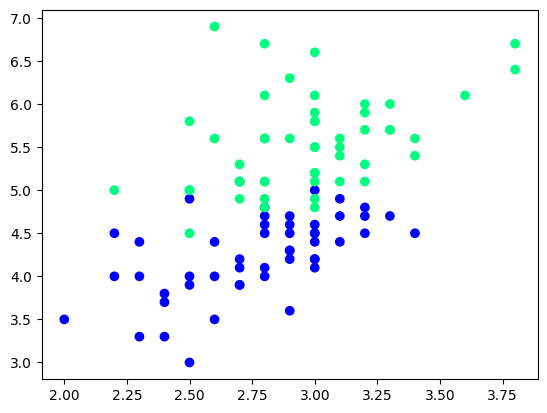

In [12]:
plt.scatter(df['sepal width (cm)'],df['petal length (cm)'],c=df['target'],cmap='winter')

In [13]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [14]:
df_train

,sepal width (cm),petal length (cm),target
58,2.9,4.6,1
134,2.6,5.6,2
89,2.5,4.0,1
55,2.8,4.5,1
67,2.7,4.1,1
50,3.2,4.7,1
91,3.0,4.6,1
142,2.7,5.1,2
106,2.5,4.5,2
104,3.0,5.8,2


In [15]:
df_val

,sepal width (cm),petal length (cm),target
121,2.8,4.9,2
60,2.0,3.5,1
62,2.2,4.0,1
112,3.0,5.5,2
143,3.2,5.9,2


In [16]:
df_test

,sepal width (cm),petal length (cm),target
74,2.9,4.3,1
70,3.2,4.8,1
118,2.6,6.9,2
59,2.7,3.9,1
57,2.4,3.3,1


In [17]:
# Lets split validation dataset for 
x_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [19]:
# Verfiy
y_test

array([2, 1, 1, 2, 2])

# Case 1 - Bagging

In [30]:
# Data for Tree 1
df_bag = df_train.sample(8,replace=True)

x = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,sepal width (cm),petal length (cm),target
67,2.7,4.1,1
89,2.5,4.0,1
67,2.7,4.1,1
55,2.8,4.5,1
106,2.5,4.5,2
142,2.7,5.1,2
142,2.7,5.1,2
106,2.5,4.5,2


In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [31]:
dt_bag1 = DecisionTreeClassifier()

In [23]:
# Lets create a func for evaluation 

def evaluate(clf,x,y):
    clf.fit(x,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(x.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(x_test)
    print(accuracy_score(y_test,y_pred))

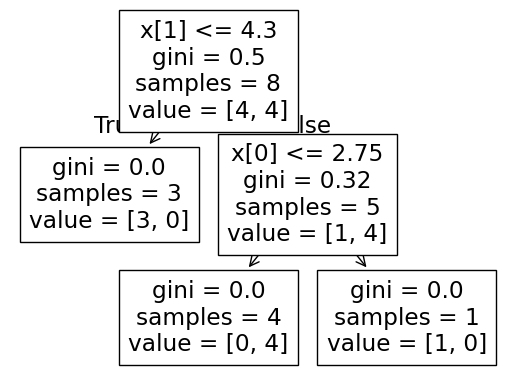

D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.4


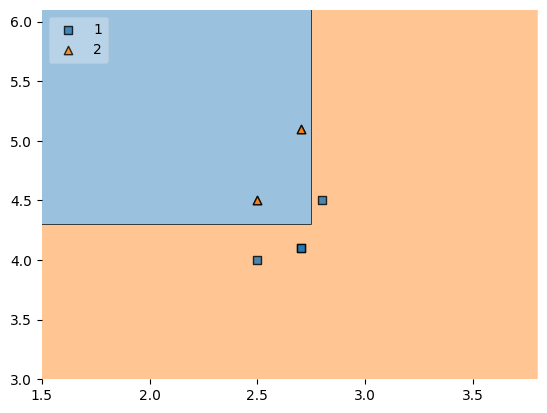

In [32]:
evaluate(dt_bag1,x,y)

In [37]:
# Data for Tree 2
df_bag2 = df_train.sample(8,replace=True)

# Fetch X and y
x = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag2

,sepal width (cm),petal length (cm),target
134,2.6,5.6,2
58,2.9,4.6,1
58,2.9,4.6,1
134,2.6,5.6,2
55,2.8,4.5,1
89,2.5,4.0,1
142,2.7,5.1,2
106,2.5,4.5,2


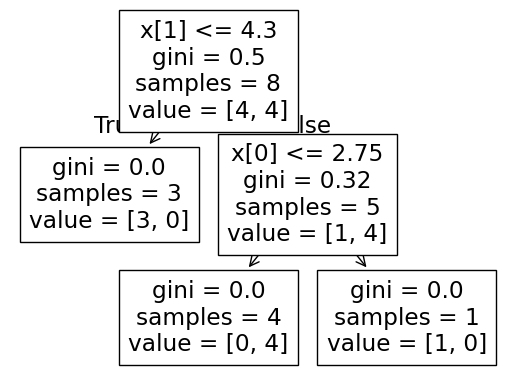

D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.4


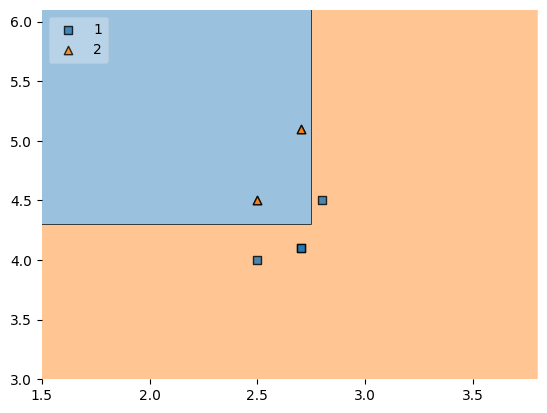

In [38]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,x,y)

In [39]:
# Data for Tree 3
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,sepal width (cm),petal length (cm),target
91,3.0,4.6,1
67,2.7,4.1,1
55,2.8,4.5,1
67,2.7,4.1,1
89,2.5,4.0,1
106,2.5,4.5,2
89,2.5,4.0,1
134,2.6,5.6,2


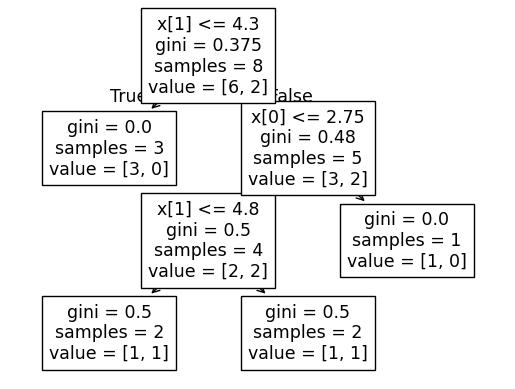

D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.4


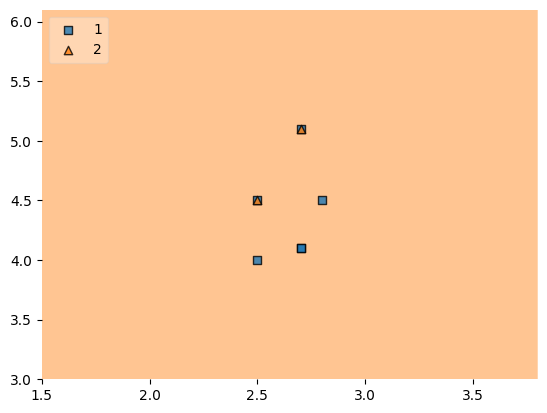

In [40]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,x,y)

# Predict

In [41]:
df_test

,sepal width (cm),petal length (cm),target
74,2.9,4.3,1
70,3.2,4.8,1
118,2.6,6.9,2
59,2.7,3.9,1
57,2.4,3.3,1


In [42]:
print("Predictor 1",dt_bag1.predict(np.array([2.6,6.9]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.6,6.9]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.6,6.9]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [1]


D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
D:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [45]:
# Since the Majoirty of the model predict the value -> 2 
# Actual value is also 2 

# Pasting

In [46]:
# Row sampling without replacement
df_train

,sepal width (cm),petal length (cm),target
58,2.9,4.6,1
134,2.6,5.6,2
89,2.5,4.0,1
55,2.8,4.5,1
67,2.7,4.1,1
50,3.2,4.7,1
91,3.0,4.6,1
142,2.7,5.1,2
106,2.5,4.5,2
104,3.0,5.8,2


In [47]:
df_train.sample(8)

,sepal width (cm),petal length (cm),target
106,2.5,4.5,2
50,3.2,4.7,1
91,3.0,4.6,1
104,3.0,5.8,2
55,2.8,4.5,1
142,2.7,5.1,2
89,2.5,4.0,1
58,2.9,4.6,1


In [48]:
# Diff between Bagging & Pasting is that value will Redundancy (Means no repeated rows) 

# Random Subspaces

In [49]:
iris = load_iris()

df1= pd.DataFrame(iris.data,columns=iris.feature_names)

df1['target'] = iris.target

df1 = df1.sample(10)

In [50]:
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
48,5.3,3.7,1.5,0.2,0
135,7.7,3.0,6.1,2.3,2
32,5.2,4.1,1.5,0.1,0
26,5.0,3.4,1.6,0.4,0
3,4.6,3.1,1.5,0.2,0
82,5.8,2.7,3.9,1.2,1
35,5.0,3.2,1.2,0.2,0
143,6.8,3.2,5.9,2.3,2
40,5.0,3.5,1.3,0.3,0
60,5.0,2.0,3.5,1.0,1


In [54]:
# Choosing random 2 cols for trainig (Repetation Allowed)
df1.sample(2,replace=True,axis=1)

,petal width (cm),sepal width (cm)
48,0.2,3.7
135,2.3,3.0
32,0.1,4.1
26,0.4,3.4
3,0.2,3.1
82,1.2,2.7
35,0.2,3.2
143,2.3,3.2
40,0.3,3.5
60,1.0,2.0


# Random Patches

In [55]:
df1

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
48,5.3,3.7,1.5,0.2,0
135,7.7,3.0,6.1,2.3,2
32,5.2,4.1,1.5,0.1,0
26,5.0,3.4,1.6,0.4,0
3,4.6,3.1,1.5,0.2,0
82,5.8,2.7,3.9,1.2,1
35,5.0,3.2,1.2,0.2,0
143,6.8,3.2,5.9,2.3,2
40,5.0,3.5,1.3,0.3,0
60,5.0,2.0,3.5,1.0,1


In [56]:
# Choosing random 2 cols for trainig (Repetation NOT Allowed)
df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,target,petal width (cm)
35,0,0.2
3,0,0.2
35,0,0.2
143,2,2.3
135,2,2.3
35,0,0.2
3,0,0.2
32,0,0.1
